In [71]:
import pandas as pd
import json
%matplotlib inline
import matplotlib.pyplot as plt

In [84]:
with open('forecast.json', 'r') as f:
    raw = json.load(f)

forecast_df = pd.json_normalize(raw['data'])

In [85]:
with open('prodData.json', 'r') as f:
    raw = json.load(f)

prod_data_df = pd.json_normalize(raw['data'])

In [86]:
for df,columns in [(forecast_df,['publishTime','startTime']),(prod_data_df,['publishTime','startTime'])]:
    for column in columns:
         df[column] = pd.to_datetime(df[column], utc=True)

In [87]:
forecast_df['generation'] = pd.to_numeric(forecast_df['generation'])
prod_data_df['generation'] = pd.to_numeric(prod_data_df['generation'])

In [88]:
horizons = [1,10,20,40]

In [89]:
forecast_df_sorted = forecast_df.sort_values(by='publishTime',ascending=True)

In [90]:
prod_data_df_sorted = prod_data_df.sort_values(by='startTime')

In [91]:
data_map = {st: {} for st in forecast_df['startTime'].unique()}

In [92]:
for horizon in horizons:
    for _, row in forecast_df_sorted.iterrows():
        start_time = row['startTime']
        publish_time = row['publishTime']
        generation = row['generation']

        diff_hours = (start_time - publish_time).total_seconds() / 3600

        
        if diff_hours >= horizon:
            if start_time in data_map:
                data_map[start_time][horizon] = generation

In [95]:
for _, row in prod_data_df.iterrows():
    start_time = row['startTime']
    actual_generation = row['generation']

    if start_time not in data_map:
        data_map[start_time] = {}

    data_map[start_time]['actual'] = actual_generation

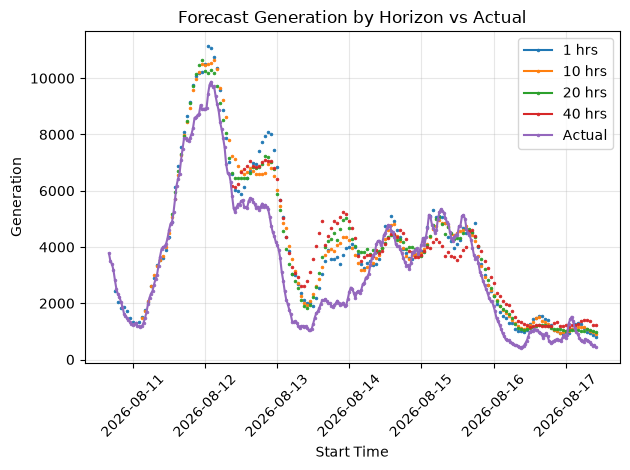

In [99]:



sorted_items = sorted(data_map.items())

start = pd.Timestamp(prod_data_df_sorted['startTime'].iloc[0])
end = pd.Timestamp(prod_data_df_sorted['startTime'].iloc[-1])

filtered_sorted_item = [(t, v) for t, v in sorted_items if start <= t <= end]


x = [start_time for start_time, _ in filtered_sorted_item]

all_keys = set()
for _, values in sorted_items:    
    for key in values.keys():        
        all_keys.add(key)

series_keys = sorted(all_keys, key=lambda k: (isinstance(k, str), k))

labels = {
    key: f"{key} hrs" if isinstance(key, (int, float)) else str(key).capitalize()
    for key in series_keys
}

for key in series_keys:
    y = [values.get(key, float('nan')) for _, values in filtered_sorted_item]
    y_filled = pd.Series(y, index=x).ffill()
    plt.plot(x, y, marker='o', markersize=2,
    markeredgewidth=0.5,  label=labels[key])

plt.title("Forecast Generation by Horizon vs Actual")
plt.xlabel("Start Time")
plt.ylabel("Generation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()







In [103]:
devaiton_df = pd.DataFrame.from_dict(data_map, orient='index')
df.index.name = 'timestamp'

In [104]:
deviations = devaiton_df[horizons].sub(devaiton_df['actual'], axis=0)

In [115]:
print(deviations)

                               1     10     20     40
2026-08-16 20:00:00+00:00  385.0  390.0  436.0  642.0
2026-08-16 21:00:00+00:00  308.0  282.0  376.0  604.0
2026-08-16 22:00:00+00:00  253.0  262.0  386.0  498.0
2026-08-16 23:00:00+00:00  134.0  201.0  275.0  417.0
2026-08-17 00:00:00+00:00  217.0  236.0  253.0  469.0
...                          ...    ...    ...    ...
2026-08-10 20:30:00+00:00    NaN    NaN    NaN    NaN
2026-08-10 19:30:00+00:00    NaN    NaN    NaN    NaN
2026-08-10 18:30:00+00:00    NaN    NaN    NaN    NaN
2026-08-10 17:30:00+00:00    NaN    NaN    NaN    NaN
2026-08-10 16:30:00+00:00    NaN    NaN    NaN    NaN

[383 rows x 4 columns]


In [116]:
mean_deviation = deviations.mean()

In [117]:
print(mean_deviation)

1     659.608696
10    684.644737
20    738.845070
40    839.852459
dtype: float64


In [118]:
mean_perc = (deviations.abs().div(devaiton_df['actual'], axis=0)).mean() * 100

In [119]:
print(mean_perc)

1     35.780692
10    39.284313
20    41.950194
40    63.999311
dtype: float64
